In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df = sns.load_dataset('titanic')

In [3]:
df .head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [5]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [6]:
df['deck'].value_counts()

deck
C    59
B    47
D    33
E    32
A    15
F    13
G     4
Name: count, dtype: int64

> ## Q1: What are the Overall Survival rate?

In [7]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [8]:
df['survived'].value_counts(normalize=True)*100

survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

> ## Q2: What is the Serivial rate difference, between Male vs Female?

<Axes: xlabel='sex', ylabel='survived'>

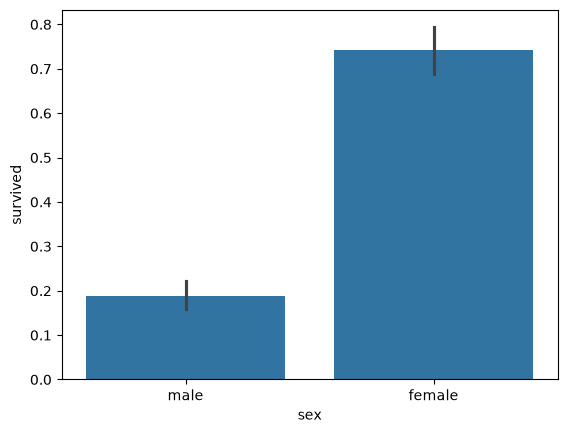

In [9]:
sns.barplot(x='sex',y='survived',data=df)

> ## Q3: What is the survival rate for P_class?

<Axes: xlabel='pclass', ylabel='survived'>

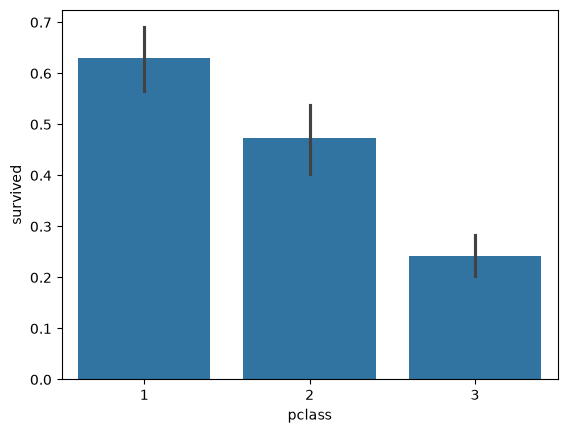

In [10]:
sns.barplot(x='pclass',y='survived',data=df)

# Age & family.
## Kids vs Adults Vs Elderly - which category servived more

<Axes: xlabel='age', ylabel='Count'>

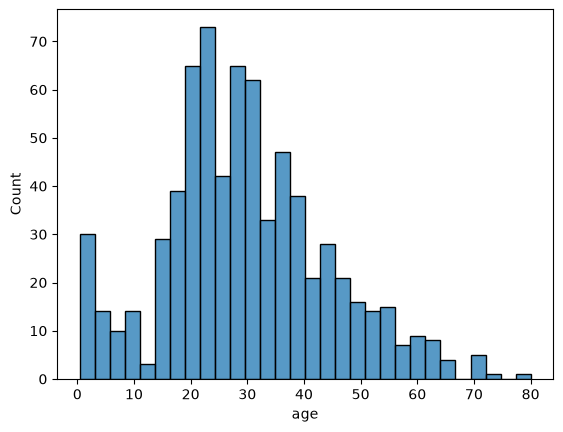

In [11]:
sns.histplot(df['age'].dropna(),bins=30)

> ## family Travel Vs alone Travel  what was the rate of servival difference?

In [12]:
df['family_size'] = df['sibsp']+ df['parch']+1

In [13]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1


<Axes: xlabel='family_size', ylabel='survived'>

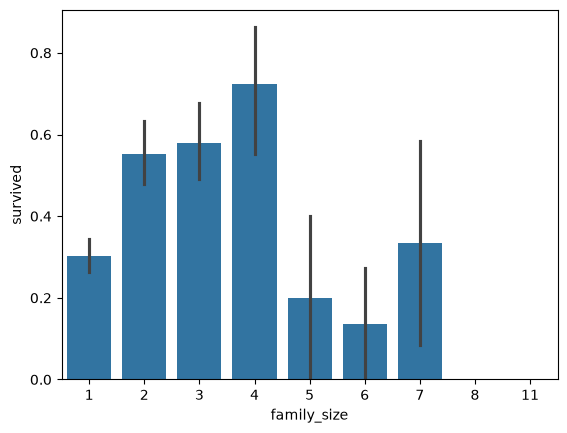

In [14]:
sns.barplot(x=df['family_size'],y=df['survived'])

> ## From which location the passenger servived more.

In [15]:
emb_sur = df.groupby('embark_town')['survived'].sum()

In [16]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Location the Passenger Servived more.')

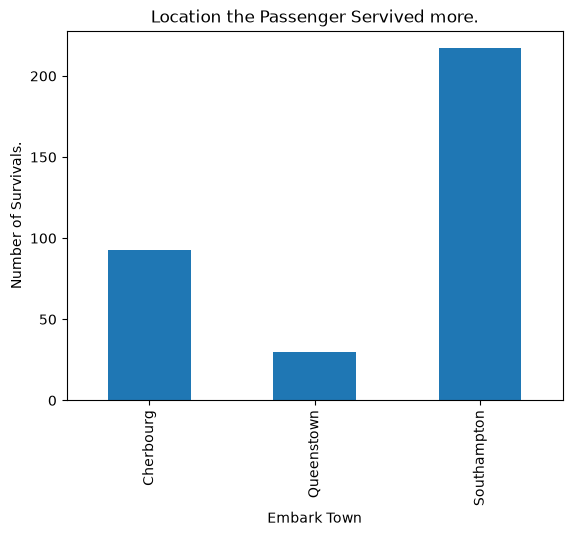

In [17]:
emb_sur.plot(kind='bar')
plt.xlabel('Embark Town')
plt.ylabel('Number of Survivals.')
plt.title('Location the Passenger Servived more.')

In [18]:
df.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2


In [19]:
women_1st_class = df[(df['sex'] == 'female') & (df['pclass']==1)]

In [20]:
# Survival Rate.
survival_rate = women_1st_class['survived'].mean()*100
print(f'Women + 1st Class Survival Rate: {survival_rate}')

Women + 1st Class Survival Rate: 96.80851063829788


In [21]:
#Number of Total Womens in 1st class.
print(f'Total women in 1st Class: {len(women_1st_class)}')
# Number of Survived Womens from 1st class.
print(f'Total Survived {women_1st_class['survived'].sum()}')


Total women in 1st Class: 94
Total Survived 91


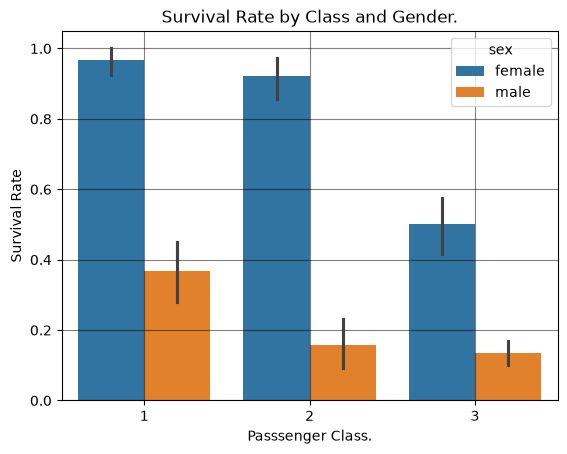

In [22]:
sns.barplot(x='pclass',y='survived',hue='sex',data=df)
plt.title('Survival Rate by Class and Gender.')
plt.ylabel('Survival Rate')
plt.xlabel('Passsenger Class.')
plt.grid(alpha=0.5,color='black')
plt.show()

> ## Save data to a file.

In [23]:
df.to_csv('Titanic.csv',index=False)